In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [8]:
from google.colab import files
uploaded = files.upload()

filename = list(uploaded.keys())[0]
df = pd.read_csv(filename)
df.head()


Saving Dataset  (1).csv to Dataset  (1) (1).csv


,Restaurant ID,Restaurant Name,Country Code,City,Address,Locality,Locality Verbose,Longitude,Latitude,Cuisines,...,Currency,Has Table booking,Has Online delivery,Is delivering now,Switch to order menu,Price range,Aggregate rating,Rating color,Rating text,Votes
0,6317637,Le Petit Souffle,162,Makati City,"Third Floor, Century City Mall, Kalayaan Avenu...","Century City Mall, Poblacion, Makati City","Century City Mall, Poblacion, Makati City, Mak...",121.027535,14.565443,"French, Japanese, Desserts",...,Botswana Pula(P),Yes,No,No,No,3,4.8,Dark Green,Excellent,314
1,6304287,Izakaya Kikufuji,162,Makati City,"Little Tokyo, 2277 Chino Roces Avenue, Legaspi...","Little Tokyo, Legaspi Village, Makati City","Little Tokyo, Legaspi Village, Makati City, Ma...",121.014101,14.553708,Japanese,...,Botswana Pula(P),Yes,No,No,No,3,4.5,Dark Green,Excellent,591
2,6300002,Heat - Edsa Shangri-La,162,Mandaluyong City,"Edsa Shangri-La, 1 Garden Way, Ortigas, Mandal...","Edsa Shangri-La, Ortigas, Mandaluyong City","Edsa Shangri-La, Ortigas, Mandaluyong City, Ma...",121.056831,14.581404,"Seafood, Asian, Filipino, Indian",...,Botswana Pula(P),Yes,No,No,No,4,4.4,Green,Very Good,270
3,6318506,Ooma,162,Mandaluyong City,"Third Floor, Mega Fashion Hall, SM Megamall, O...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.056475,14.585318,"Japanese, Sushi",...,Botswana Pula(P),No,No,No,No,4,4.9,Dark Green,Excellent,365
4,6314302,Sambo Kojin,162,Mandaluyong City,"Third Floor, Mega Atrium, SM Megamall, Ortigas...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.057508,14.584450,"Japanese, Korean",...,Botswana Pula(P),Yes,No,No,No,4,4.8,Dark Green,Excellent,229


In [9]:

print(df.columns)
df.rename(columns={
    'Aggregate rating': 'Aggregate_rating',
    'Price range': 'Price_range'
}, inplace=True)

df[['Price_range', 'Aggregate_rating', 'Rating color']].head()


Index(['Restaurant ID', 'Restaurant Name', 'Country Code', 'City', 'Address',
       'Locality', 'Locality Verbose', 'Longitude', 'Latitude', 'Cuisines',
       'Average Cost for two', 'Currency', 'Has Table booking',
       'Has Online delivery', 'Is delivering now', 'Switch to order menu',
       'Price range', 'Aggregate rating', 'Rating color', 'Rating text',
       'Votes'],
      dtype='object')


,Price_range,Aggregate_rating,Rating color
0,3,4.8,Dark Green
1,3,4.5,Dark Green
2,4,4.4,Green
3,4,4.9,Dark Green
4,4,4.8,Dark Green


Most Common Price Ranges:
 Price_range
1    4444
2    3113
3    1408
4     586
Name: count, dtype: int64


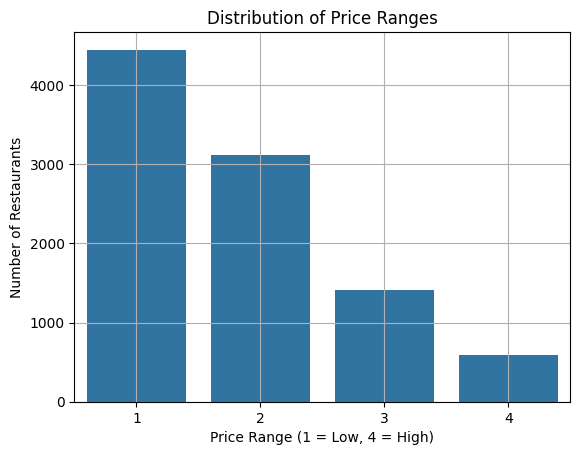

In [10]:
# Frequency of each price range
price_freq = df['Price_range'].value_counts()
print("Most Common Price Ranges:\n", price_freq)

sns.countplot(data=df, x='Price_range')
plt.title("Distribution of Price Ranges")
plt.xlabel("Price Range (1 = Low, 4 = High)")
plt.ylabel("Number of Restaurants")
plt.grid(True)
plt.show()


Average Ratings by Price Range:
 Price_range
1    1.999887
2    2.941054
3    3.683381
4    3.817918
Name: Aggregate_rating, dtype: float64


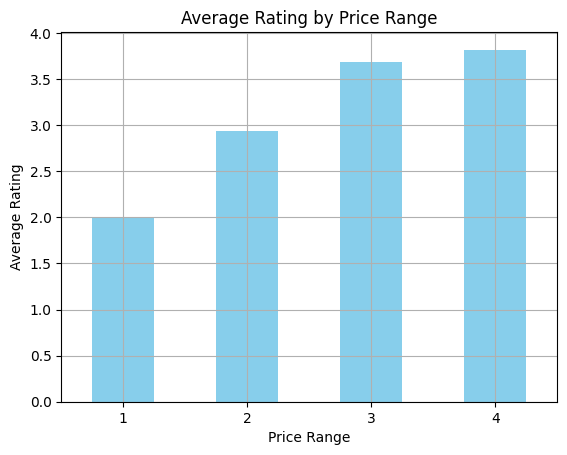

In [11]:
avg_rating_by_price = df.groupby('Price_range')['Aggregate_rating'].mean()
print("Average Ratings by Price Range:\n", avg_rating_by_price)

# Visualize
avg_rating_by_price.plot(kind='bar', color='skyblue')
plt.title("Average Rating by Price Range")
plt.xlabel("Price Range")
plt.ylabel("Average Rating")
plt.xticks(rotation=0)
plt.grid(True)
plt.show()


In [12]:
# Find color associated with highest average rating
rating_color = df.groupby('Price_range')['Rating color'].agg(lambda x: x.mode()[0])
combined = pd.DataFrame({
    'Average Rating': avg_rating_by_price,
    'Rating Color': rating_color
})
print("Color by Price Range:\n", combined)

# Highlight the best one
best = combined['Average Rating'].idxmax()
print(f"\n🎯 Highest average rating is for Price Range {best} with color: {combined.loc[best, 'Rating Color']}")


Color by Price Range:
              Average Rating Rating Color
Price_range                             
1                  1.999887       Orange
2                  2.941054       Orange
3                  3.683381       Yellow
4                  3.817918       Yellow

🎯 Highest average rating is for Price Range 4 with color: Yellow
